[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2026/blob/main/Y1/notebooks/3-euclid-zoo_cnn_vit.ipynb)

# Galaxy zoo image classification - basics with PyTorch
## Ecole Rodolphe Cledassou 2026

> Marc Huertas-Company & Hubert Bretonnière 

This notebook illustrates how to train a simple CNN and ViT from scratch to estimate the morphologies of galaxies observed with the Euclid Space Telescope. The training set is composed of galaxy stamps labeled by visual inspection through citizen science

In [1]:
import numpy as np
import torch
import numpy as np
import os, shutil, glob
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F



In [ ]:
from datasets import load_dataset,disable_caching

PATH_TO_DATADIR = "zoo-data"

# 1) Remove global caches of imagefolder
hf_home = os.path.expanduser("~/.cache/huggingface/datasets")
for p in glob.glob(os.path.join(hf_home, "imagefolder", "default-*")):
    print("Removing global cache:", p)
    shutil.rmtree(p, ignore_errors=True)

# 2) Remove your project-local cache as well
local_cache = os.path.abspath("./.hf_cache")
print("Removing local cache:", local_cache)
shutil.rmtree(local_cache, ignore_errors=True)
os.makedirs(local_cache, exist_ok=True)

# 3) Rebuild clean
ds = load_dataset(
    "imagefolder",
    data_files={
        "train": ["zoo-data/train/*/*"],
        "test":  ["zoo-data/test/*/*"],
    },
    drop_labels=False,
    keep_in_memory=False,
    cache_dir=local_cache,
    download_mode="force_redownload",   # force a full rebuild
)
train_set, test_set = ds["train"], ds["test"]
print(train_set, test_set)

class_names = train_set.features["label"].names
# Attach a .classes attribute to both splits
for split in ("train", "test"):
    setattr(ds[split], "classes", class_names)

print(train_set.classes)
print(test_set.classes)

globals()["train_dataset_plot"] = train_set

/opt/homebrew/Caskroom/miniconda/base/envs/DL_intro_EDE/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

batch_size = 9

# 1) Define transforms (resize to fixed size, to tensor, normalize optional)
IMG_SIZE = 224  # or whatever your model expects
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                           # PIL -> [C,H,W] float in [0,1]
    # transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),  # optional
])

# 2) Collate converts PIL -> tensor (+ labels)
def collate_fn(examples):
    # If images can be grayscale, force RGB for consistent 3 channels:
    imgs = [tfm(ex["image"].convert("RGB")) for ex in examples]
    labels = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
    return torch.stack(imgs, 0), labels



trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                          shuffle=True, collate_fn=collate_fn)

testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                         shuffle=False, collate_fn=collate_fn)

globals()["train_loader_plot"] = trainloader

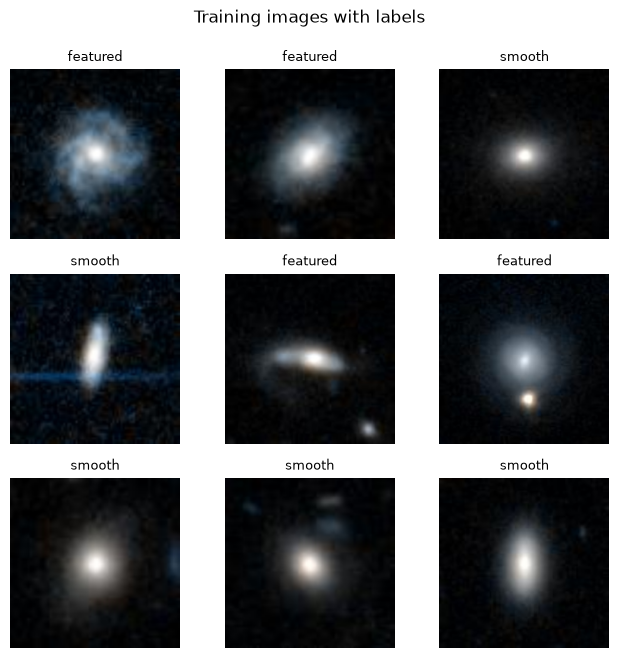

In [ ]:
g = globals()

train_loader = g.get('train_loader_plot') or g.get('train_dataloader') or g.get('loader_train') or g.get('train_dl')
train_dataset = g.get('train_dataset_plot') or g.get('train_ds') or (train_loader.dataset if train_loader is not None and hasattr(train_loader, 'dataset') else None)
assert train_dataset is not None, "Could not locate a training dataset/loader. Please run the data prep cell first."

def label_name(y):
    if hasattr(train_dataset, 'classes'):
        try: return str(train_dataset.classes[int(y)])
        except: return str(y)
    if hasattr(train_dataset, 'class_to_idx'):
        rev = {v:k for k,v in train_dataset.class_to_idx.items()}
        return str(rev.get(int(y), y))
    return str(int(y))

if train_loader is not None:
    images, labels = next(iter(train_loader))
else:
    idx = torch.randperm(len(train_dataset))[:64]
    samples = [train_dataset[i] for i in idx]
    images = torch.stack([s[0] if torch.is_tensor(s[0]) else torchvision.transforms.functional.to_tensor(s[0]) for s in samples])
    labels = torch.tensor([int(s[1]) for s in samples])

B = min(images.shape[0], 64)
R = C = int(np.ceil(np.sqrt(B)))
fig, axes = plt.subplots(R, C, figsize=(2.2*C, 2.2*R))
axes = np.array(axes).reshape(R, C)

def to_display(img):
    x = img.detach().cpu().float()
    if x.ndim == 3 and x.shape[0] in (1,3):
        if x.min() < -0.1 or x.max() > 1.1:
            x = x * 0.5 + 0.5
        x = x.clamp(0,1)
        if x.shape[0] == 1: return x.squeeze(0).numpy(), 'gray'
        else: return np.transpose(x.numpy(), (1,2,0)), None
    return x.numpy(), 'gray'

for i in range(R*C):
    ax = axes[i//C, i% C]
    ax.axis('off')
    if i >= B: continue
    img, cmap = to_display(images[i])
    ax.imshow(img, cmap=cmap)
    ax.set_title(label_name(labels[i]), fontsize=9)

plt.suptitle("Training images with labels", y=0.99)
plt.tight_layout(); plt.show()

## Defining data augmentations

This will use the transformations defined in https://albumentations.ai/docs/ to augment the datasets

In [ ]:
import albumentations as A
import cv2
import numpy as np

data_augmentation_pipeline = A.Compose([
    A.Rotate(
        limit=180,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        value=(0, 0, 0),         # fill color if you rotate out of frame (RGB)
        always_apply=True
    ),
    A.RandomResizedCrop(
        size=(224, 224),         # v2: use size=(H, W)
        scale=(0.7, 0.8),
        ratio=(0.9, 1.1),
        interpolation=cv2.INTER_LINEAR,
        always_apply=True
    ),
    A.VerticalFlip(p=0.5),
    A.ToFloat(max_value=255.0, always_apply=True),
])

def augment_func(samples):
    samples["pixel_values"] = [
        data_augmentation_pipeline(image=np.array(img.convert("RGB")))["image"]
        for img in samples["image"]
    ]
    return samples

train_set.set_transform(augment_func)
globals()["train_dataset"] = train_set


ModuleNotFoundError: No module named 'albumentations'

In [ ]:

standardization_pipeline = A.Compose([
    A.Resize(height=224, width=224, interpolation=1), 
    A.ToFloat(max_value=255.0, always_apply=True),
])

def standardize_func(samples):
    samples["pixel_values"] = [
        standardization_pipeline(image=np.array(image))["image"] for image in samples["image"]
    ]
    return samples

test_set.set_transform(standardize_func)

## Creating a convolutional network to extract features from the images from scratch

In [ ]:

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()  # for completeness (Linux/Windows)
    else torch.device("cpu")
)
print("Using:", device)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.conv3 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 4)
        x = self.dropout1(x)
        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


cnn_model = Net().to(device)